# 01｜從資料到線性模型

第一週主線；對應 `01_機器學習概觀.md` 的實例式／模型式學習、線性模型與梯度下降。建議選讀／操作 20 分鐘。目標：說明模型假設、讀取係數，並觀察學習率對損失的影響。

## 來源與改編界線
- [ageron/handson-mlp / 01_the_machine_learning_landscape.ipynb](https://github.com/ageron/handson-mlp/blob/47eba45aacc85feae51ba7db68dd1ca66cb25e0a/01_the_machine_learning_landscape.ipynb)：儲存格 10 的 GDP／生活滿意度範例
- [leonjyentub/MachineLearning2025 / 01_batchgradientDescent.ipynb](https://github.com/leonjyentub/MachineLearning2025/blob/3da2cb56b9efd17d7cd34602589f392554b40603/01_batchgradientDescent.ipynb)：批次梯度下降更新流程
- [ageron/handson-mlp / 04_training_linear_models.ipynb](https://github.com/ageron/handson-mlp/blob/47eba45aacc85feae51ba7db68dd1ca66cb25e0a/04_training_linear_models.ipynb)：Linear Regression、Gradient Descent 章節

**本課程修改／補充：** 保留 GDP 案例與 LinearRegression；加入 k-NN 對照、標準化座標上的可重現 GD、學習率比較。GDP 範例只演示建模，不報告未經驗證的泛化能力。

來源固定至上述 commit；原檔保留於 `../upstream/`，逐檔 SHA-256 見 `../upstream/manifest.json`。Géron 程式依 Apache-2.0 改編，授權原文保留。儲存格索引從 0 起算。圖表與數值是本 Notebook 重跑結果，不能直接當成書中成效。

從第一格依序執行；各本可獨立重跑。Python 環境與資料準備見 [操作說明](../README.md)。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import ROOT, DATA, OUT, SEED, FAST, setup, savefig, report, data_path
setup()

{'profile': 'fast',
 'seed': 42,
 'data': '/Users/leonjye/Documents/MacProject/MLCourse2026/programs/data'}

## 1. 用 GDP 預測生活滿意度
此為來源教材採用的歷史 OECD／World Bank 資料，不是最新國情或因果研究。

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
life = pd.read_csv(data_path('lifesat.csv'))
X = life[['GDP per capita (USD)']]
y = life['Life satisfaction']
linear = LinearRegression().fit(X,y)
knn = KNeighborsRegressor(n_neighbors=3).fit(X,y)
query = pd.DataFrame({'GDP per capita (USD)':[33442.8]})
print('Rows:', len(life), ' slope:', linear.coef_[0], ' intercept:', linear.intercept_)
pd.DataFrame({'model':['Linear regression','3-nearest neighbors'],
              'prediction':[linear.predict(query)[0],knn.predict(query)[0]]})

Rows: 27  slope: 6.778899694341222e-05  intercept: 3.7490494273769093


,model,prediction
0,Linear regression,6.016103
1,3-nearest neighbors,5.733333


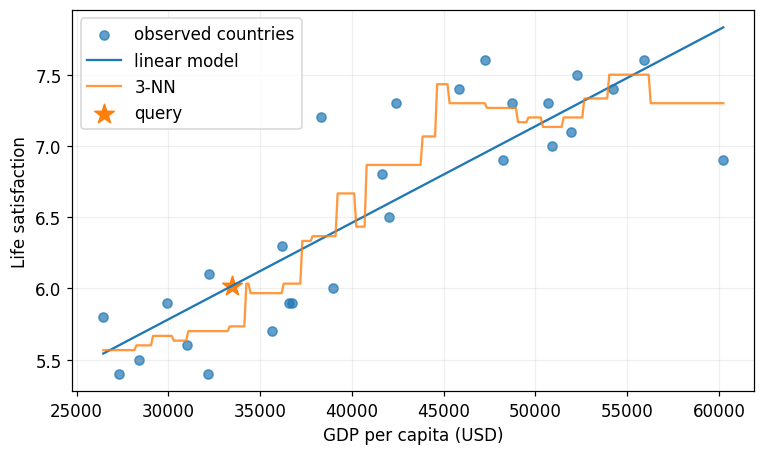

In [3]:
grid = pd.DataFrame({'GDP per capita (USD)':np.linspace(X.min().iloc[0], X.max().iloc[0],300)})
plt.scatter(X.iloc[:,0],y,label='observed countries',alpha=.7)
plt.plot(grid.iloc[:,0],linear.predict(grid),label='linear model')
plt.plot(grid.iloc[:,0],knn.predict(grid),label='3-NN',alpha=.8)
plt.scatter(query.iloc[:,0],linear.predict(query),marker='*',s=180,label='query')
plt.xlabel('GDP per capita (USD)'); plt.ylabel('Life satisfaction'); plt.legend()
savefig('01_lifesat_linear_knn')

**先預測再觀察：** k-NN 與線性模型在資料邊界外會怎樣？每人 GDP 增加一美元的斜率，能解讀成政策造成的效果嗎？

<details><summary>參考答案</summary>k-NN 使用附近已知樣本，邊界外通常維持邊界鄰居的平均；線性模型會沿直線外推。兩者都未保證域外準確。這是觀察相關，不能由斜率推論因果。</details>

## 2. 自行算出同一條迴歸線

為了讓學習率有可比較的尺度，先把 GDP 標準化。設計矩陣第一欄為 1；MSE 梯度為 $2X^T(Xw-y)/m$。這是批次更新，每一步使用全部訓練點。

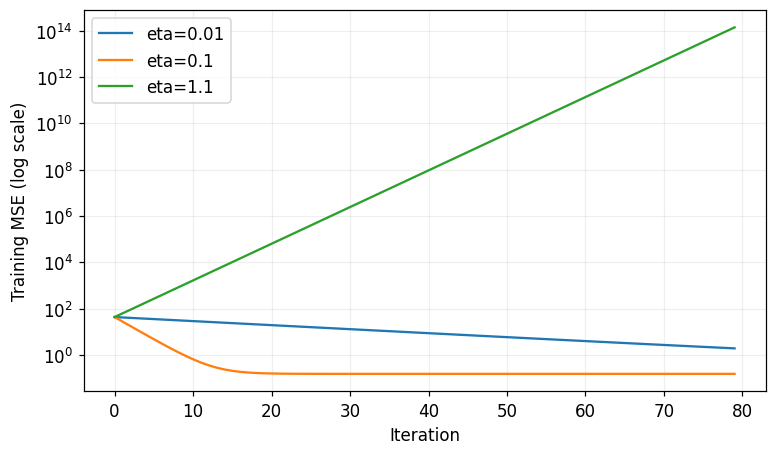

,learning_rate,last_logged_MSE
0,0.01,1.942593e+00
1,0.10,1.539460e-01
2,1.10,1.410723e+14


In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X)
Z = np.c_[np.ones(len(X)), scaler.transform(X)]
target = y.to_numpy()
def batch_gd(Z, target, eta, epochs=80):
    w = np.zeros(Z.shape[1])
    history = []
    for _ in range(epochs):
        error = Z @ w - target
        history.append(np.mean(error**2))
        w -= eta * (2/len(Z)) * Z.T @ error
    return w, np.array(history)
rows = []
for eta in [.01,.1,1.1]:
    w, loss = batch_gd(Z,target,eta)
    rows.append({'learning_rate':eta,'last_logged_MSE':loss[-1]})
    plt.semilogy(loss,label=f'eta={eta}')
plt.xlabel('Iteration'); plt.ylabel('Training MSE (log scale)'); plt.legend()
savefig('01_gradient_learning_rate')
pd.DataFrame(rows)

In [5]:
w, loss = batch_gd(Z,target,.1,epochs=200)
w_closed = np.linalg.lstsq(Z,target,rcond=None)[0]
assert np.allclose(w,w_closed,atol=1e-8)
assert np.allclose(Z@w,linear.predict(X),atol=1e-8)
report('linear', {'gdp_query':33442.8,'linear_prediction':linear.predict(query)[0],
                  'knn_prediction':knn.predict(query)[0], 'gd_weights_standardized':w.tolist()})
pd.DataFrame({'GD':w, 'least_squares':w_closed},index=['intercept','standardized GDP coefficient'])

,GD,least_squares
intercept,6.566667,6.566667
standardized GDP coefficient,0.640702,0.640702


## 練習：修改一項假設

將 k 改成 1 與 7，觀察曲線；先寫下你預期的平滑度。保留這組資料作示範，若要比較預測效果，另設驗證流程，不能只比較訓練線是否貼近散點。

**離堂檢核：** 係數是參數，k 與學習率是超參數。GD 求解與模型選擇是不同層次的工作。